# **Cattle Detection and Tracking Using YOLOv5**

**1. Cloning The YOLOv5 repository (Do this part only once)**

In [1]:
!pwd

/content


In [2]:
#clone YOLOv5
!git clone https://github.com/ultralytics/yolov5

# Change the current working directory.
%cd yolov5 
# !pip install -qr requirements.txt # install dependencies from requirements to use Yolov5 with quiet option

Cloning into 'yolov5'...
remote: Enumerating objects: 15973, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 15973 (delta 87), reused 116 (delta 75), pack-reused 15831
Receiving objects: 100% (15973/15973), 14.60 MiB | 5.11 MiB/s, done.
Resolving deltas: 100% (10956/10956), done.
/content/yolov5


In [3]:
%pip install ultralytics

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.4/595.4 kB 30.4 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Import Required Libraries**

In [5]:
import shutil
import os
from random import choice

import torch
import os
from IPython.display import Image  # to display images
from ultralytics import YOLO

**3. Loading the dataset (Do this part only once)**


In [6]:
# source path
raw_train_img = "../raw_dataset/train/images"
raw_train_label = "../raw_dataset/train/labels"
raw_val_img = "../raw_dataset/valid/images"
raw_val_label = "../raw_dataset/valid/labels"

raw_test_img = "../raw_dataset/test/images"
raw_test_label = "../raw_dataset/test/labels"

In [7]:
# Destination path
train_image_path = "../datasets2/images/train"
train_label_path = "../datasets2/labels/train"
val_image_path = "../datasets2/images/val"
val_label_path = "../datasets2/labels/val"


test_image_path = "../datasets2/images/test"
test_label_path = "../datasets2/labels/test"

In [8]:
# copy files from source directory into dest directory
shutil.copytree(raw_train_img, train_image_path)
shutil.copytree(raw_train_label, train_label_path)
shutil.copytree(raw_val_img, val_image_path)
shutil.copytree(raw_val_label, val_label_path)

'../datasets2/labels/val'

In [9]:
shutil.copytree(raw_test_img, test_image_path)
shutil.copytree(raw_test_label, test_label_path)

'../datasets2/labels/test'

**4-Check dataset**

In [10]:
# Checking the size of images and displaying them
import numpy as np
import cv2

# Image shape in Training
image = cv2.imread('../datasets2/images/train/4818b4db76e1a51e2743ac9ca5b1eae7_jpg.rf.4bfa0d1602b206b40b19fc36d5fb2d81.jpg')
height = np.size(image, 0)
width = np.size(image, 1)
print ("shape of the training image {}, {}".format(height, width))

# Image shape in validation
image = cv2.imread('../datasets2/images/val/DJI_0064_JPG_jpg.rf.8806c859c43f8960106e68ee22642947.jpg')
height = np.size(image, 0)
width = np.size(image, 1)
print ("shape of the validation image {}, {}".format(height, width))

shape of the training image 640, 640
shape of the validation image 640, 640


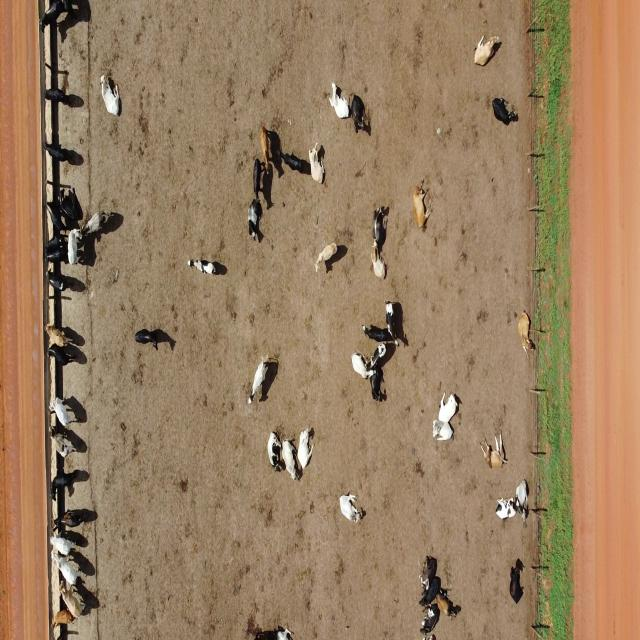

In [11]:
# dispying with different width
Image(filename='../datasets2/images/train/4818b4db76e1a51e2743ac9ca5b1eae7_jpg.rf.4bfa0d1602b206b40b19fc36d5fb2d81.jpg', width=416) 

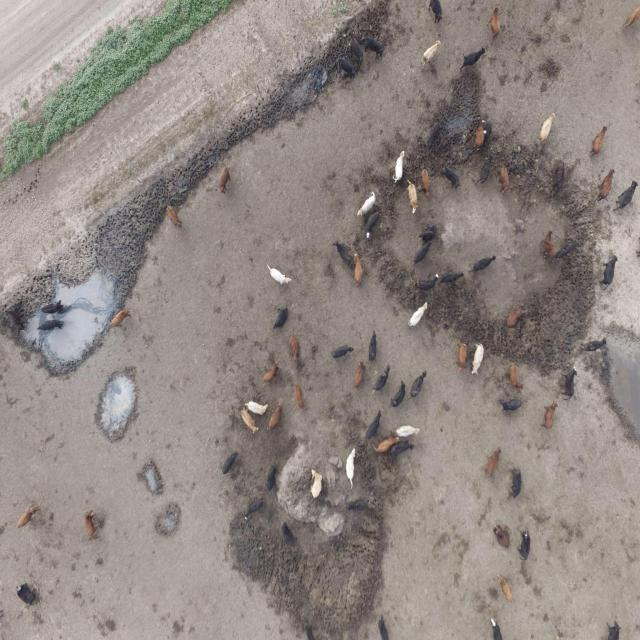

In [12]:
# dispying with different width
Image(filename='../datasets2/images/val/DJI_0064_JPG_jpg.rf.8806c859c43f8960106e68ee22642947.jpg', width=416) 

**5. Create traffic_sign_data.yaml (dataset config file)**

"traffic sign data" is a small dataset composed of the first 374 images in train and 88 images in validation set. 

data/traffic_sign_data.yaml, created below, is the dataset config file that defines:

1) the dataset root directory path and relative paths to train / val / test image directories (or *.txt files with image paths)

2) nc: the number of classes

3) names: a list of class names

In [13]:
import yaml

result = {
    "train": f"../datasets2/images/train", # train images 
    "val": f"../datasets2/images/val",     # val images 
    "nc": 1,                              # number of classes
    "names": ['cow'],  # class names
}
with open("./data/cow_data.yaml", "w") as f:
    dump = yaml.dump(result, default_flow_style=False)
    f.write(dump)

**6. Training Our Custom Traffic Sign Detector Model**

I am training a YOLOv5s model on traffic sign data by specifying dataset, batch-size, image size and pretrained --weights yolov5s.pt. Pretrained weights are auto-downloaded from the latest YOLOv5 release.

Parameters:

–data: Path to the data configuration file

--weights: specify a path to weights to start transfer learning from. yolov5s.pt (starting from Pretrained weights)

–img: Input image size

–batch: Size of a batch (model weights are updated with each batch).

–epochs: No of epochs.

--cache: cache images for faster training, cache images in "ram" (default) or "disk

In [14]:
# Training YOLOv5s on traffic sign dataset for 30 epochs
!python train.py --img 600 --batch 9 --epochs 30 --data cow_data.yaml --weights yolov5s.pt --cache

requirements: Ultralytics requirement "gitpython" not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.3/184.3 kB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 312.8 MB/s eta 0:00:00

requirements: 1 package updated per ['gitpython']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect

train: weights=yolov5s.pt, cfg=, data=cow_data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=9, imgsz=600, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None,

All training results are saved to runs/train/ with incrementing run directories, i.e. runs/train/exp2, runs/train/exp3 etc.

**7-Local Logging:**

All results are logged by default to runs/train, with a new experiment directory created for each new training as runs/train/exp2, runs/train/exp3, etc. View train and val jpgs to see mosaics, labels, predictions and augmentation effects. Note an Ultralytics Mosaic Dataloader is used for training (shown below), which combines 4 images into 1 mosaic during training.

val_batch0_labels.jpg shows validation batch 0 mosaics and labels:

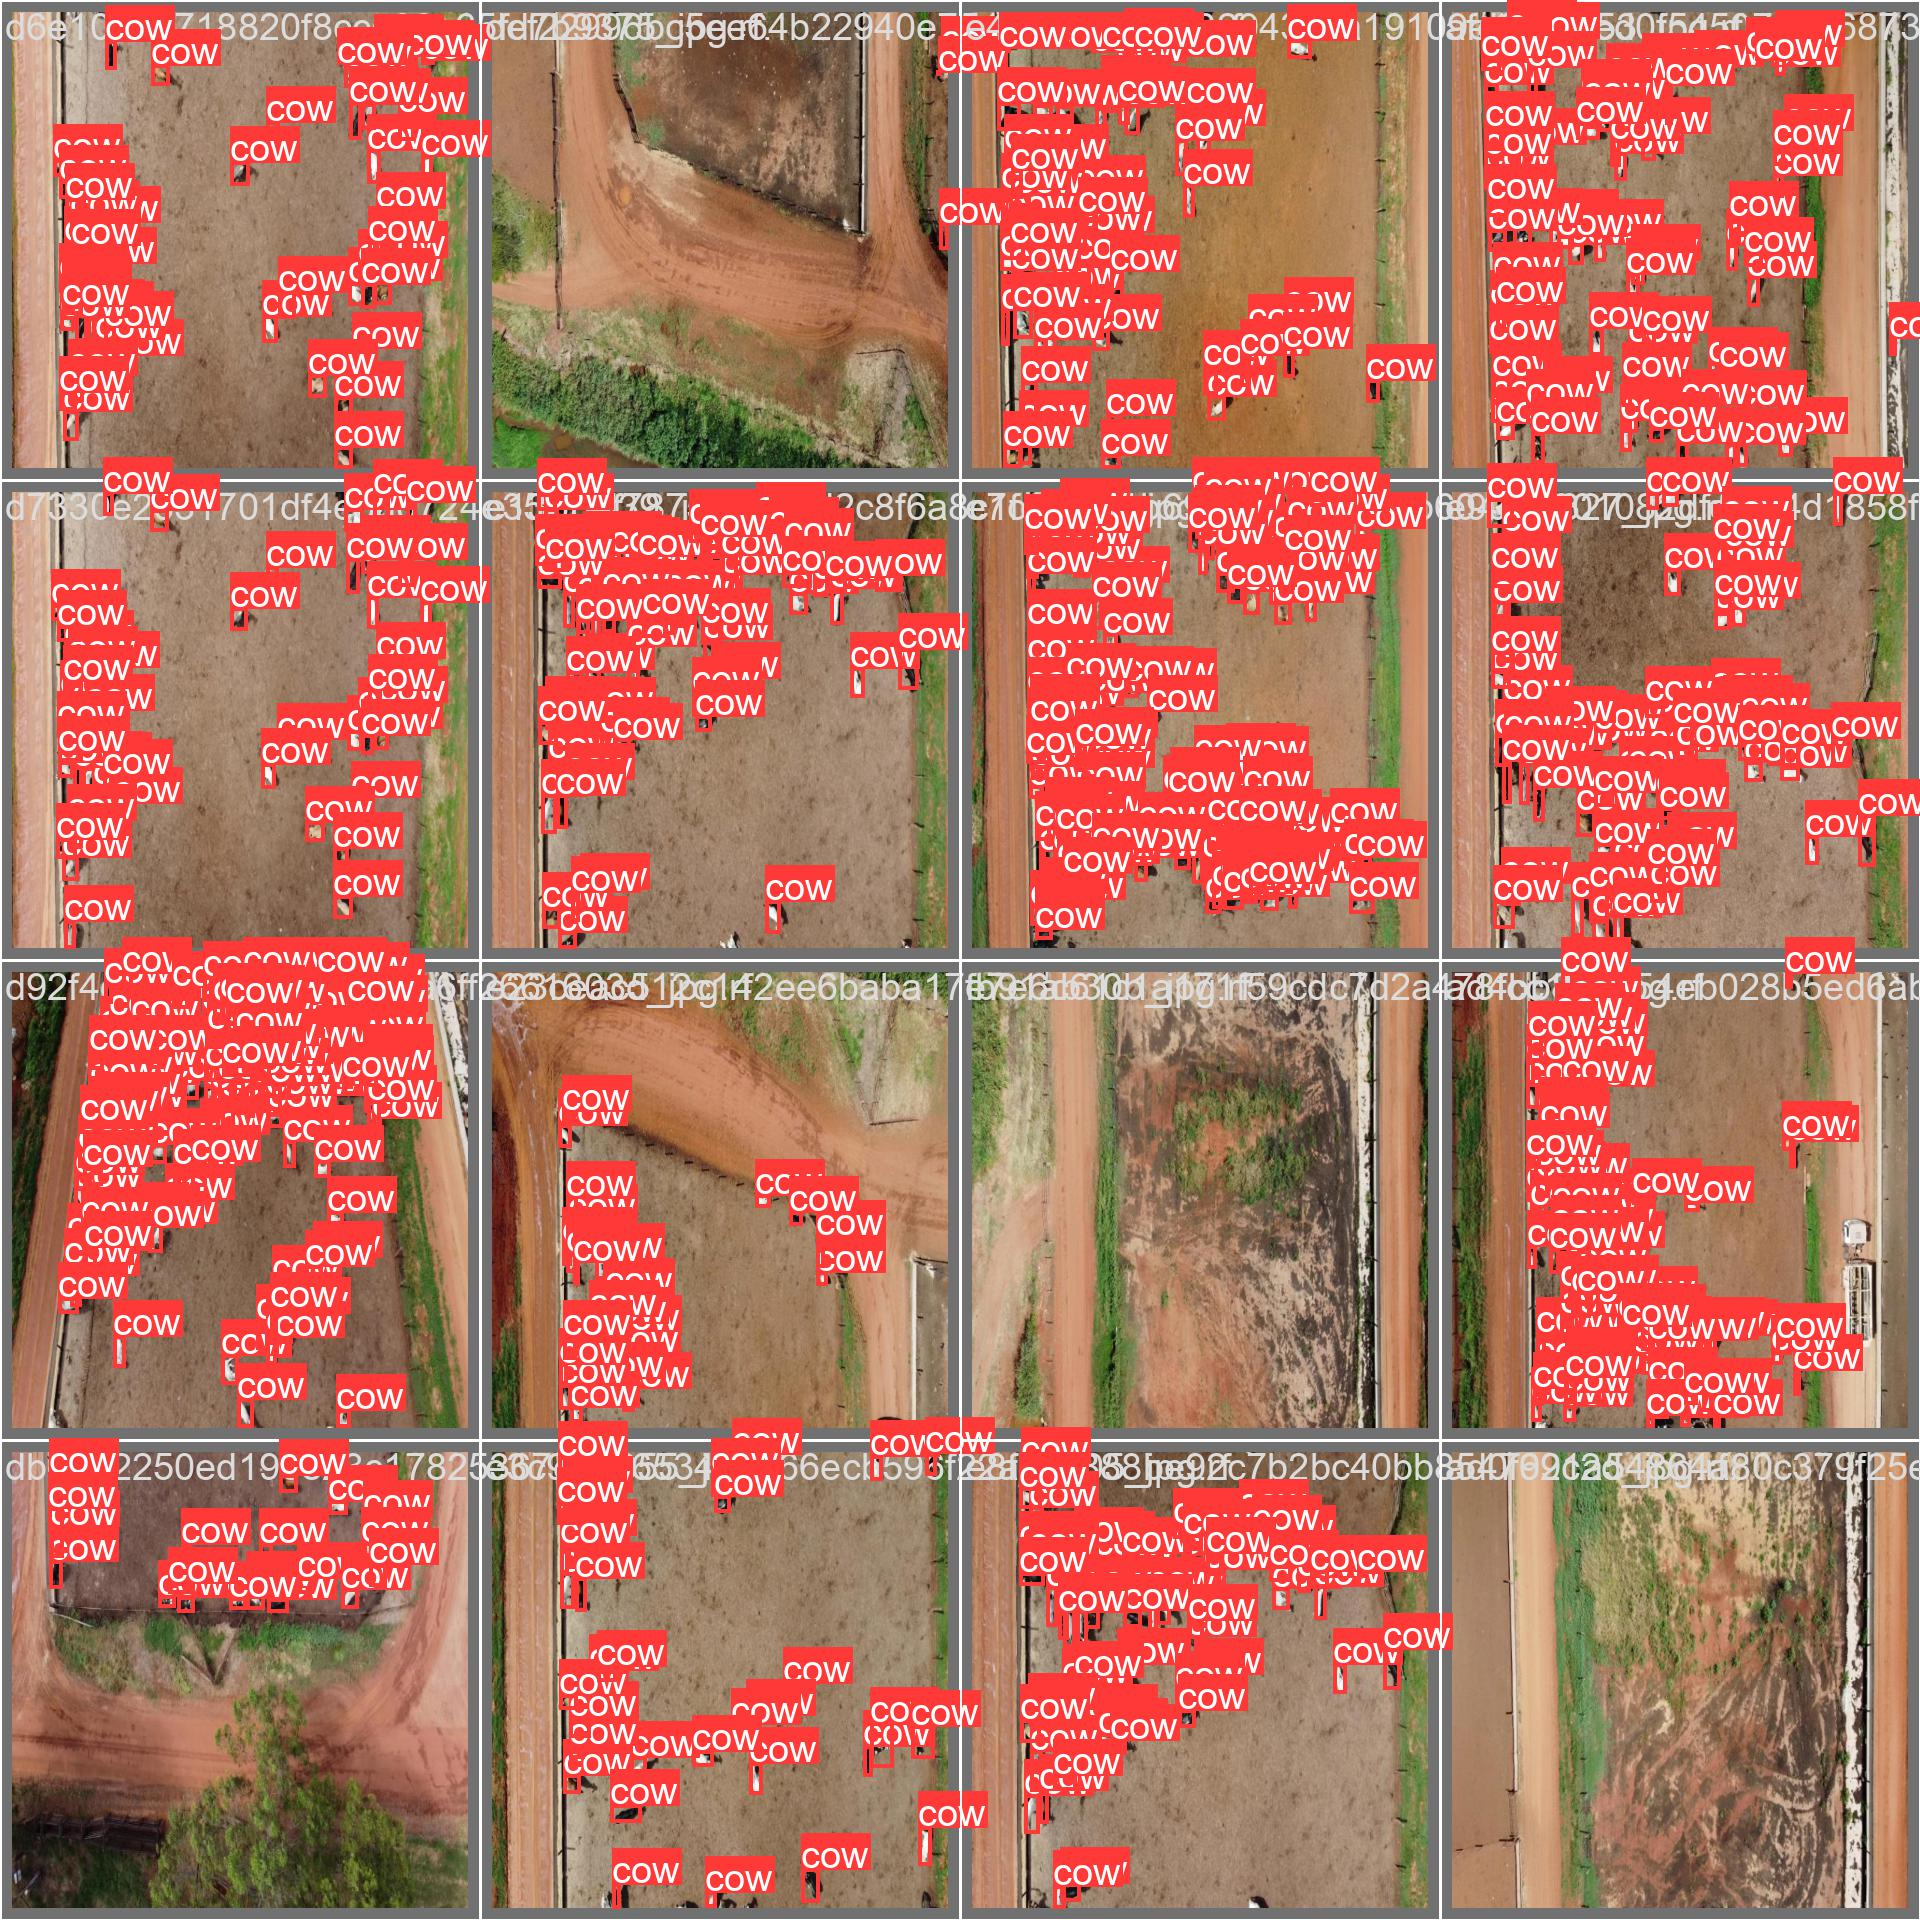

In [15]:
#Image(filename='/content/yolov5/runs/train/exp/train_batch0.jpg', width=800)  # train batch 0 mosaics and labels
Image(filename='./runs/train/exp/val_batch1_labels.jpg', width=800)  # test batch 0 labels
#Image(filename='/content/yolov5/runs/train/exp/val_batch0_pred.jpg', width=800)  # test batch 0 predictions

Training losses and performance metrics are also logged to Tensorboard and a custom results.txt logfile which is plotted as results.png (below) after training completes.

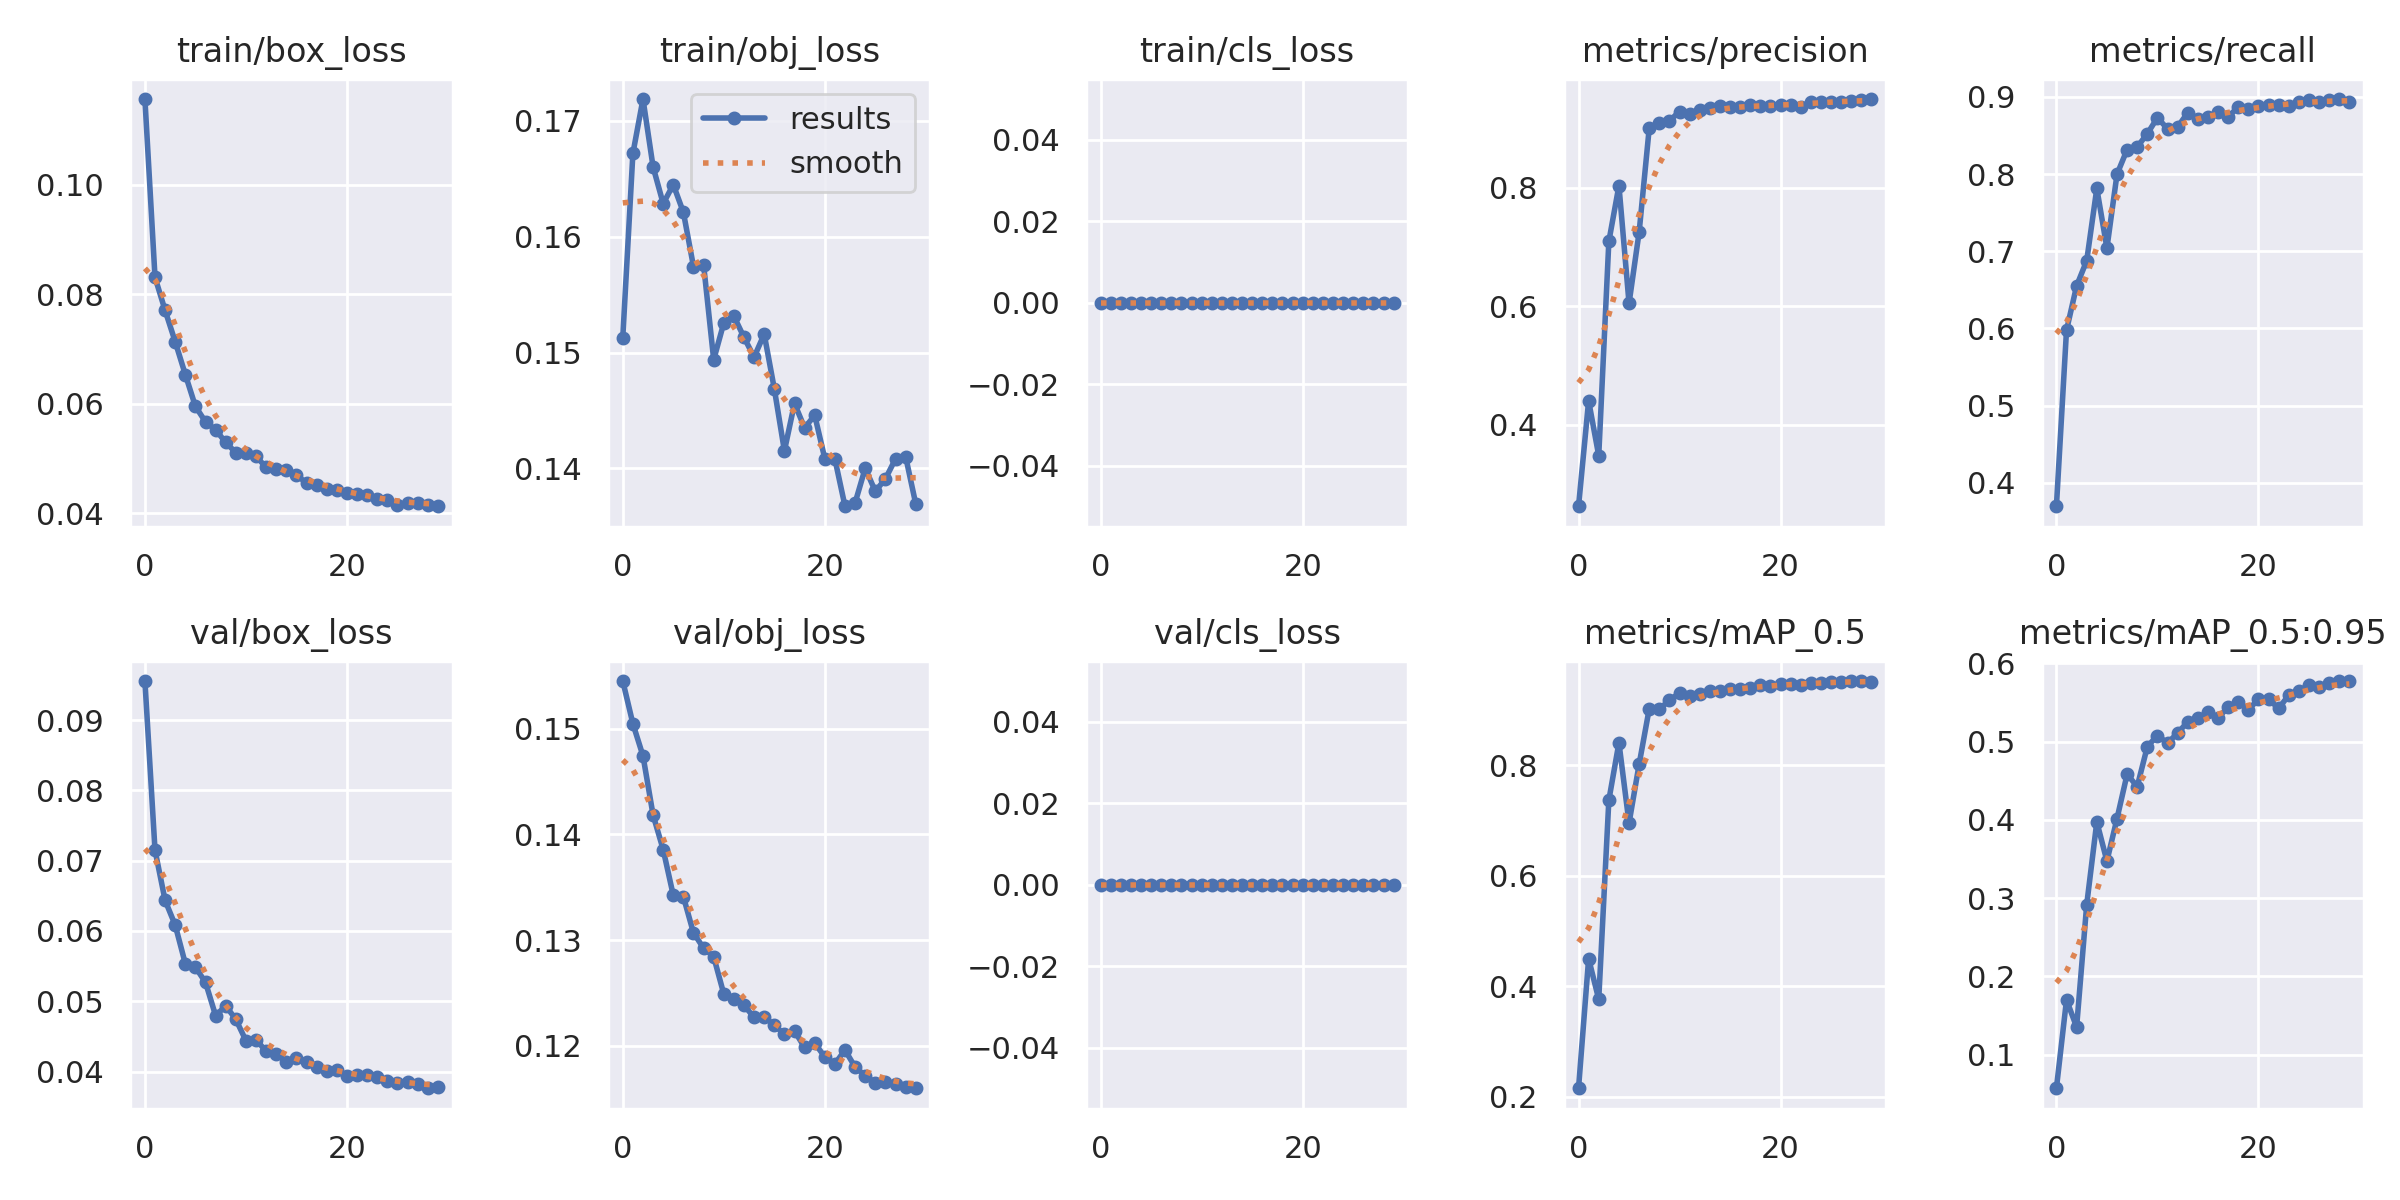

In [16]:
Image(filename='./runs/train/exp/results.png', width=800)

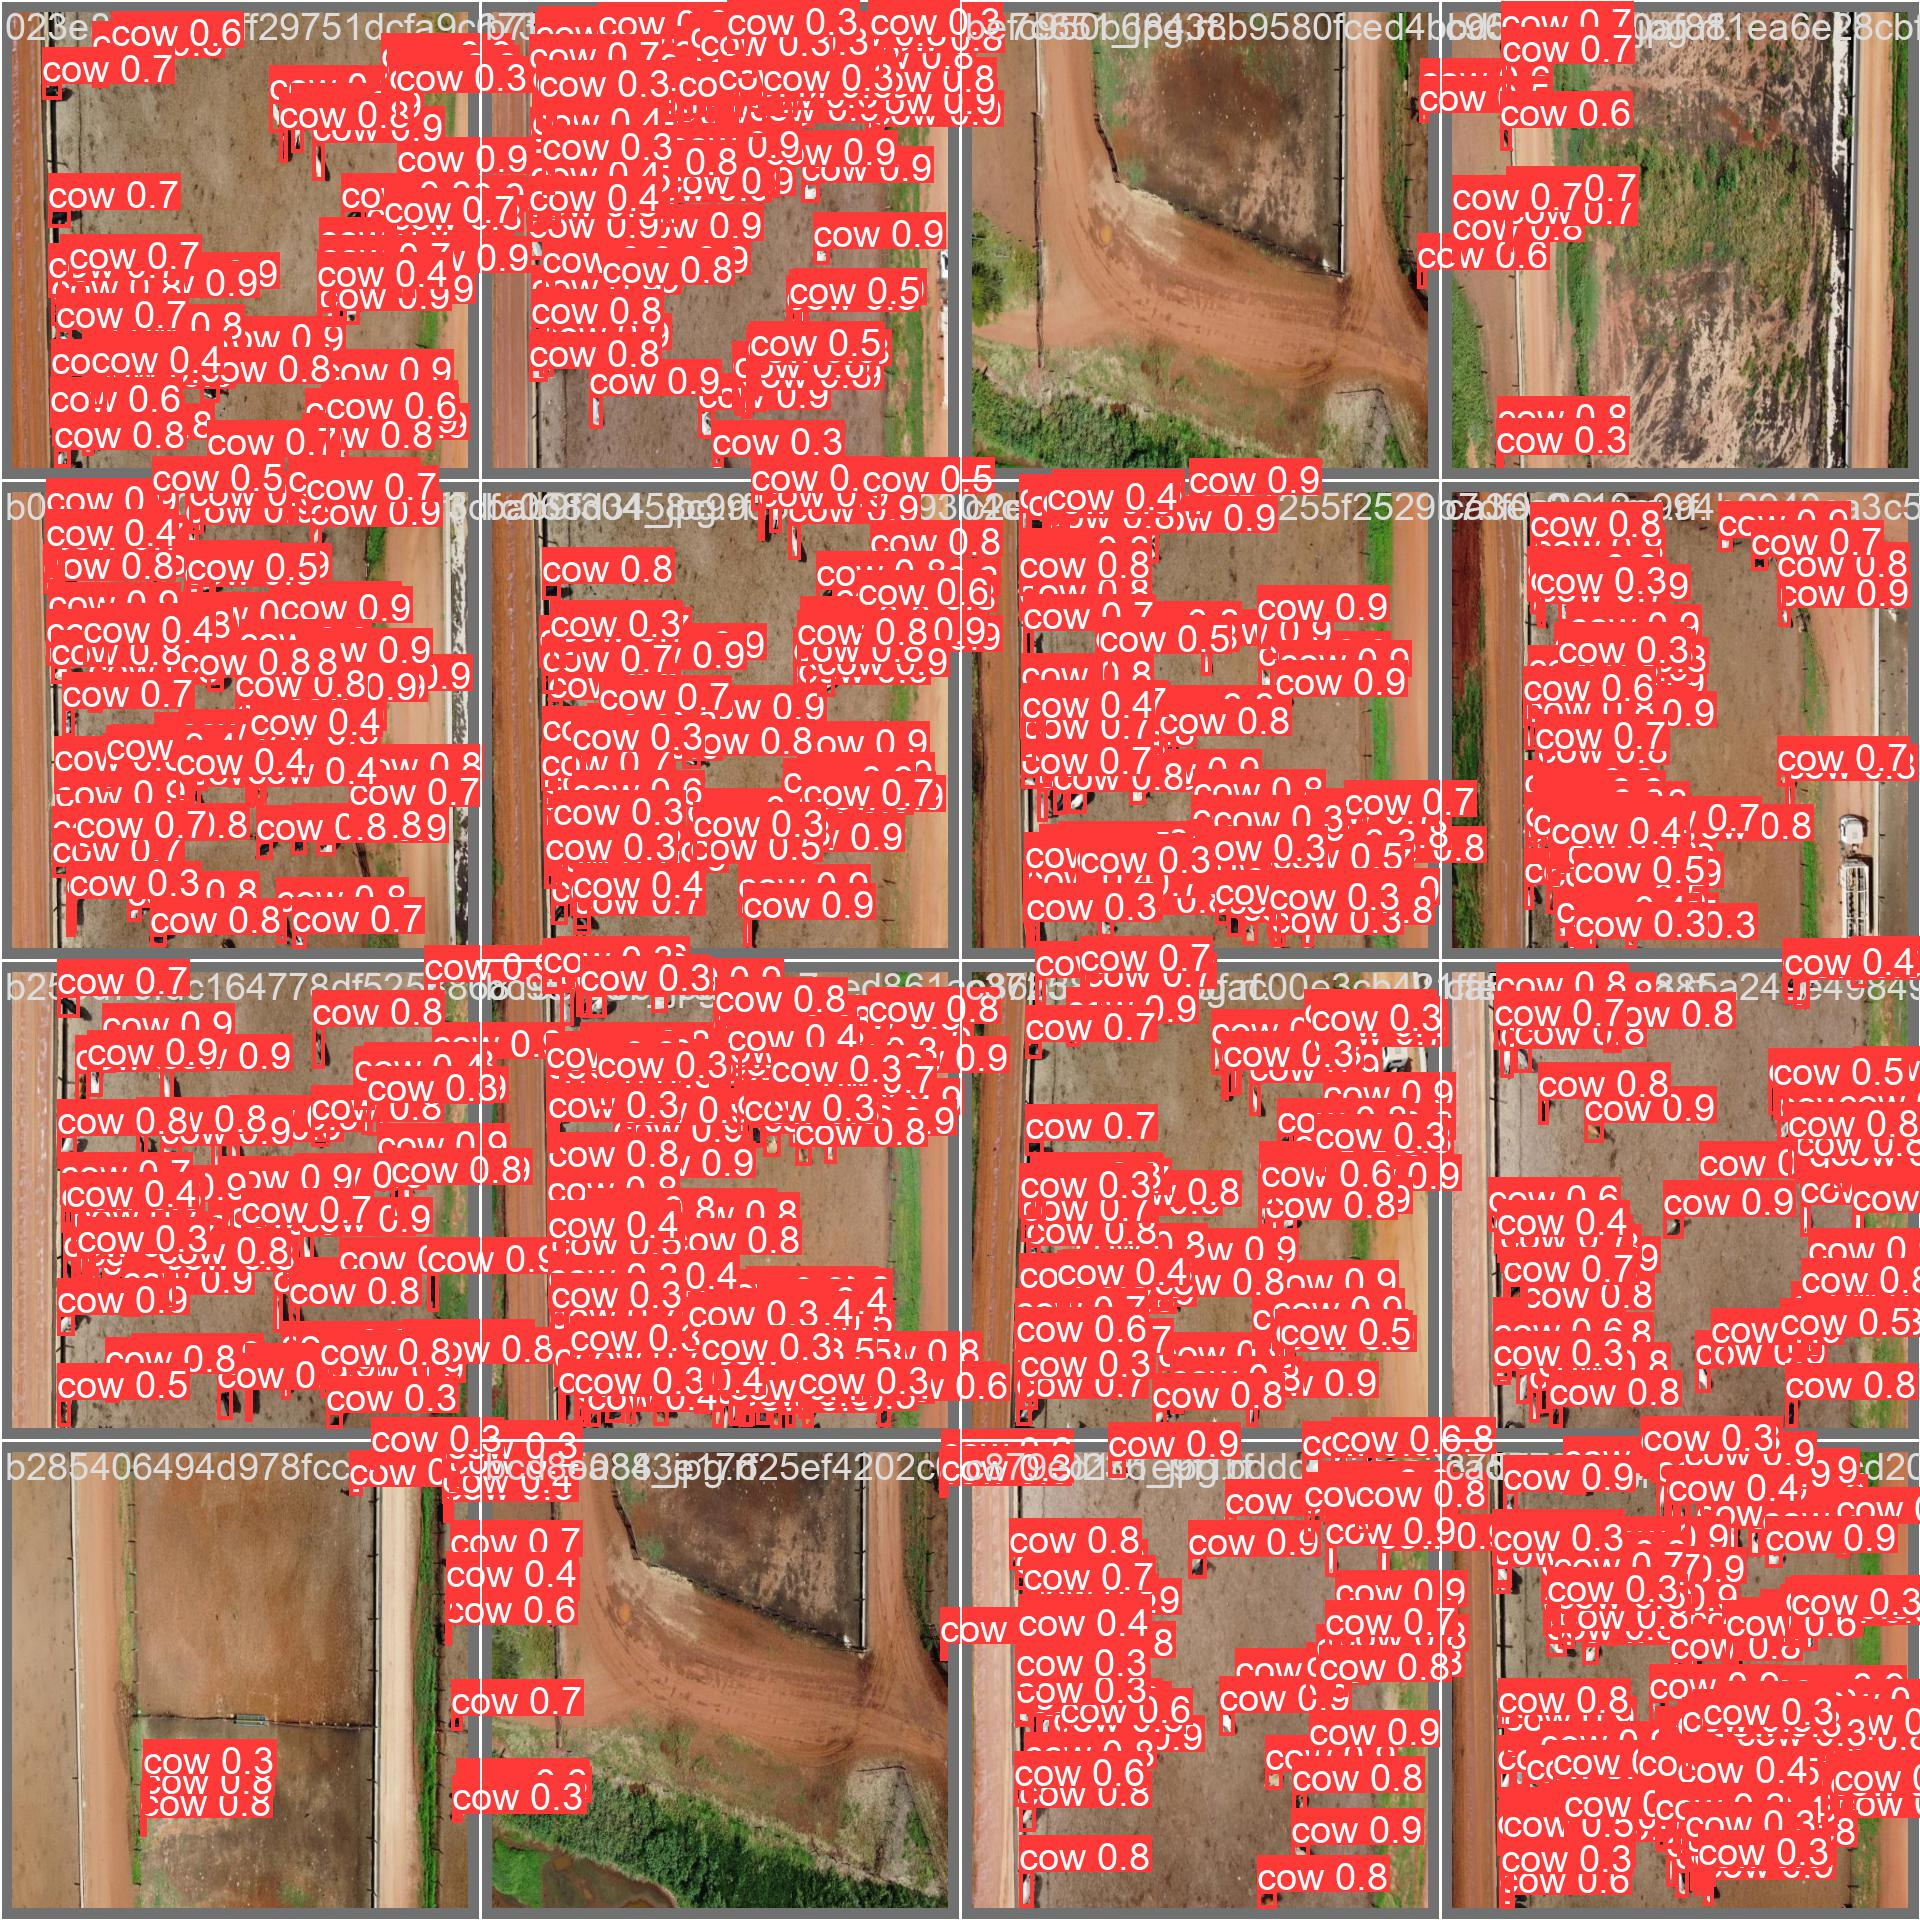

In [17]:
Image(filename='./runs/train/exp/val_batch0_pred.jpg', width=800)

 **6. Run Inference With Custom YOLOv5 Object Detector Trained Weights**

Inference Command: Run the ‘detect.py’ file to run inference on the custom dataset.

–source: The path to the image to perform inference on.

–weights: Weights file of the trained model.


–conf: Minimum confidence value to consider a prediction as good.

–save-txt: Flag parameters enables saving of text files containing the coordinates of bounding boxes.

**Inference on Images:**

In [18]:
!python detect.py --source ../datasets2/images/test/6bfad02b487e438d3e3698ff3d0c27bb_jpg.rf.037882a01d90fcb501d1fbc95ee8d1a2.jpg --weights runs/train/exp/weights/best.pt --conf 0.5 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/images/test/6bfad02b487e438d3e3698ff3d0c27bb_jpg.rf.037882a01d90fcb501d1fbc95ee8d1a2.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/datasets2/images/test/6bfad02b487e438d3e3698ff3d0c27bb_jpg.rf.037882a01d90fcb501d1fbc95ee8d1a2.jpg: 640x640 47 cows, 11.5ms
Speed: 0.5ms pre-process, 11.5ms inference, 1.5ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp


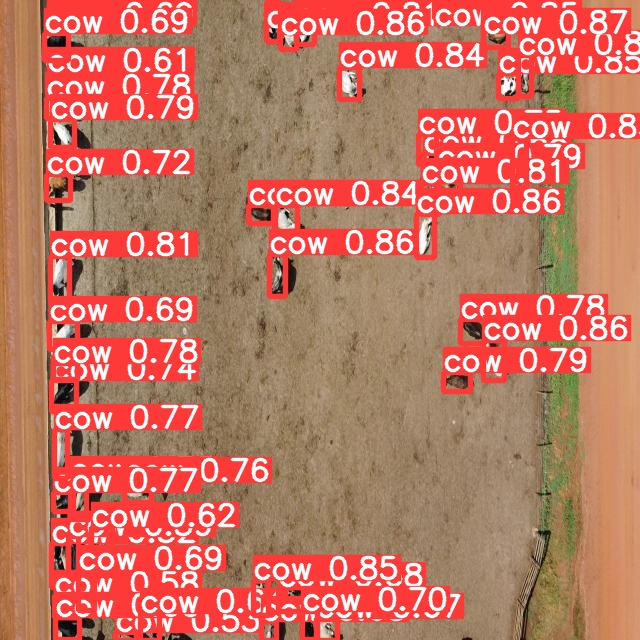

In [19]:
Image(filename='./runs/detect/exp/6bfad02b487e438d3e3698ff3d0c27bb_jpg.rf.037882a01d90fcb501d1fbc95ee8d1a2.jpg', width=800)

In [20]:
!python detect.py --source ../datasets2/images/test/DJI_0063_JPG_jpg.rf.6dc91f01f76d2ea1d646586eddfa69a7.jpg --weights runs/train/exp/weights/best.pt --conf 0.5 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/images/test/DJI_0063_JPG_jpg.rf.6dc91f01f76d2ea1d646586eddfa69a7.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/datasets2/images/test/DJI_0063_JPG_jpg.rf.6dc91f01f76d2ea1d646586eddfa69a7.jpg: 640x640 55 cows, 11.5ms
Speed: 0.6ms pre-process, 11.5ms inference, 1.5ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2
1 labels saved to runs/detect/exp2/labe

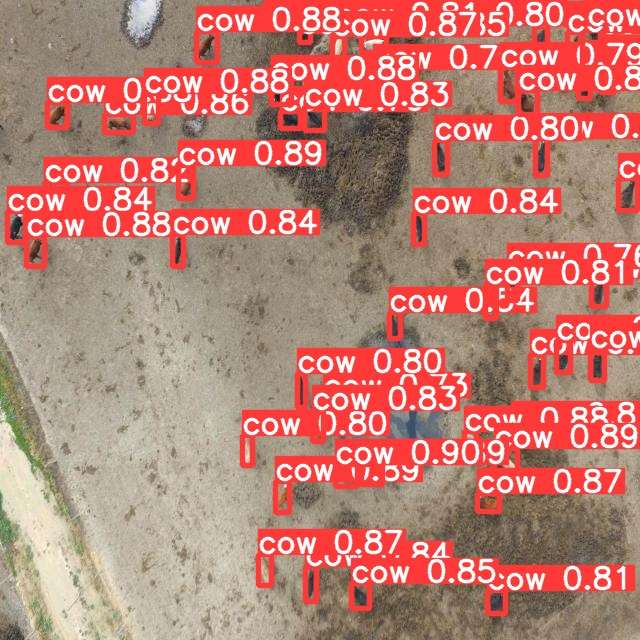

In [21]:
Image(filename='./runs/detect/exp2/DJI_0063_JPG_jpg.rf.6dc91f01f76d2ea1d646586eddfa69a7.jpg', width=800)

In [22]:
# dispying with different width
!python detect.py --source ../datasets2/images/test/a80f679b64a3c523f96ef4bfb31b9171_jpg.rf.4edc06e17efb7ad6d7a0f53e4d337aa4.jpg --weights runs/train/exp/weights/best.pt --conf 0.5 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/images/test/a80f679b64a3c523f96ef4bfb31b9171_jpg.rf.4edc06e17efb7ad6d7a0f53e4d337aa4.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/datasets2/images/test/a80f679b64a3c523f96ef4bfb31b9171_jpg.rf.4edc06e17efb7ad6d7a0f53e4d337aa4.jpg: 640x640 14 cows, 11.5ms
Speed: 0.6ms pre-process, 11.5ms inference, 1.9ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp3

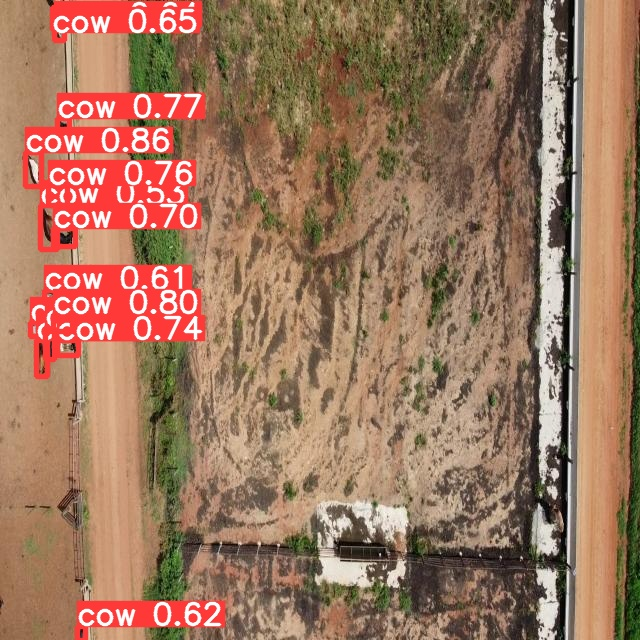

In [23]:
Image(filename='./runs/detect/exp3/a80f679b64a3c523f96ef4bfb31b9171_jpg.rf.4edc06e17efb7ad6d7a0f53e4d337aa4.jpg', width=800)

In [24]:
!python detect.py --source ../datasets2/images/test/d48a359c5c1c28f13d5c1b6cfe5f7652_jpg.rf.81942c0d4bb548f07f86a1813eaa6338.jpg --weights runs/train/exp/weights/best.pt --conf 0.5 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/images/test/d48a359c5c1c28f13d5c1b6cfe5f7652_jpg.rf.81942c0d4bb548f07f86a1813eaa6338.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/datasets2/images/test/d48a359c5c1c28f13d5c1b6cfe5f7652_jpg.rf.81942c0d4bb548f07f86a1813eaa6338.jpg: 640x640 60 cows, 11.5ms
Speed: 0.6ms pre-process, 11.5ms inference, 1.5ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp4

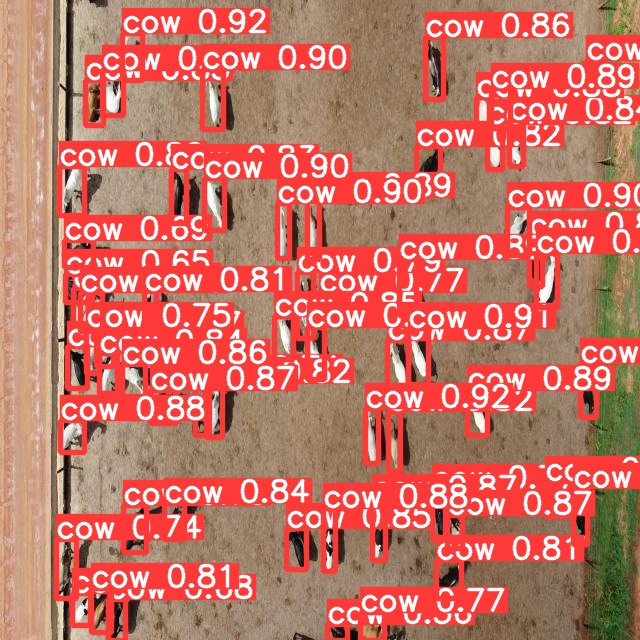

In [25]:
Image(filename='./runs/detect/exp4/d48a359c5c1c28f13d5c1b6cfe5f7652_jpg.rf.81942c0d4bb548f07f86a1813eaa6338.jpg', width=800)

In [26]:
!python detect.py --source ../datasets2/images/test/1a1c66d4ee9f6dbb059a84633d59ba38_jpg.rf.7e593dc121ec6da5b85d4945ce752bc8.jpg --weights runs/train/exp/weights/best.pt --conf 0.5 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/images/test/1a1c66d4ee9f6dbb059a84633d59ba38_jpg.rf.7e593dc121ec6da5b85d4945ce752bc8.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/datasets2/images/test/1a1c66d4ee9f6dbb059a84633d59ba38_jpg.rf.7e593dc121ec6da5b85d4945ce752bc8.jpg: 640x640 18 cows, 11.5ms
Speed: 0.5ms pre-process, 11.5ms inference, 1.5ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp5

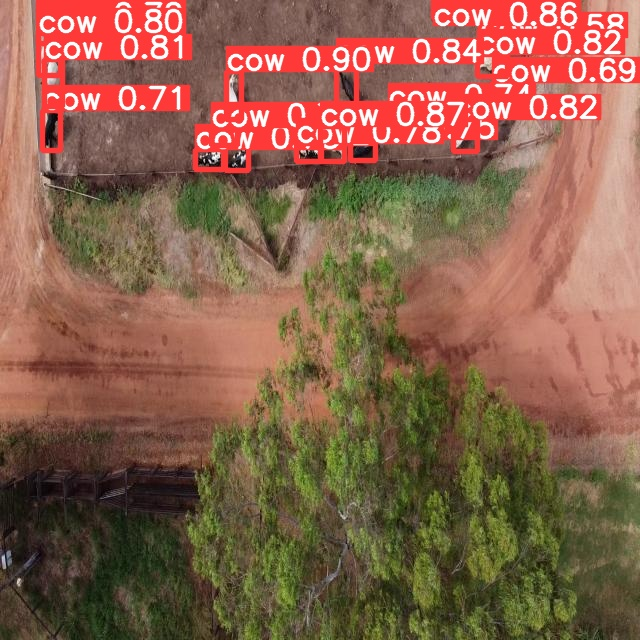

In [27]:
Image(filename='./runs/detect/exp5/1a1c66d4ee9f6dbb059a84633d59ba38_jpg.rf.7e593dc121ec6da5b85d4945ce752bc8.jpg', width=800)

In [ ]:
!python detect.py --source ../datasets2/images/test/DJI_0009_JPG.rf.524c985e90fbfd166503bb4f1dab5348.jpg --weights runs/train/exp/weights/best.pt --conf 0.5 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/images/test/DJI_0009_JPG.rf.524c985e90fbfd166503bb4f1dab5348.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-175-g5f11555 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/datasets2/images/test/DJI_0009_JPG.rf.524c985e90fbfd166503bb4f1dab5348.jpg: 640x640 75 cows, 11.5ms
Speed: 0.6ms pre-process, 11.5ms inference, 1.6ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp6
1 labels saved to runs/detect/exp6/labels


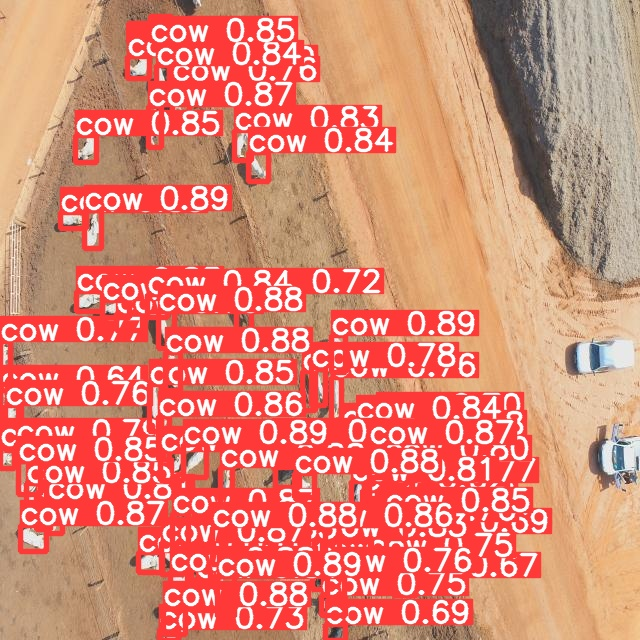

In [ ]:
Image(filename='./runs/detect/exp6/DJI_0009_JPG.rf.524c985e90fbfd166503bb4f1dab5348.jpg', width=800)

**Inference on Video:**

In [28]:
!python detect.py  --source ../datasets2/Video_1.mp4 --weights runs/train/exp/weights/best.pt --conf 0.25 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/Video_1.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/1518) /content/datasets2/Video_1.mp4: 384x640 18 cows, 41.4ms
video 1/1 (2/1518) /content/datasets2/Video_1.mp4: 384x640 17 cows, 8.0ms
video 1/1 (3/1518) /content/datasets2/Video_1.mp4: 384x640 16 cows, 8.4ms
video 1/1 (4/1518) /content/datasets2/Video_1.mp4: 384x640 16 cows, 7.9ms
video 1/1 (5/1518) /content/datasets2/Video_1

In [29]:
!python detect.py  --source ../datasets2/Video_2.mp4 --weights runs/train/exp/weights/best.pt --conf 0.25 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/Video_2.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/1054) /content/datasets2/Video_2.mp4: 384x640 32 cows, 41.7ms
video 1/1 (2/1054) /content/datasets2/Video_2.mp4: 384x640 32 cows, 8.5ms
video 1/1 (3/1054) /content/datasets2/Video_2.mp4: 384x640 33 cows, 7.9ms
video 1/1 (4/1054) /content/datasets2/Video_2.mp4: 384x640 32 cows, 8.7ms
video 1/1 (5/1054) /content/datasets2/Video_2

In [30]:
!python detect.py  --source ../datasets2/Video_3.mp4 --weights runs/train/exp/weights/best.pt --conf 0.25 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/Video_3.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/465) /content/datasets2/Video_3.mp4: 384x640 27 cows, 45.0ms
video 1/1 (2/465) /content/datasets2/Video_3.mp4: 384x640 23 cows, 10.7ms
video 1/1 (3/465) /content/datasets2/Video_3.mp4: 384x640 24 cows, 19.0ms
video 1/1 (4/465) /content/datasets2/Video_3.mp4: 384x640 21 cows, 14.6ms
video 1/1 (5/465) /content/datasets2/Video_3.m

In [33]:
!python detect.py  --source ../datasets2/Video_4.mp4 --weights runs/train/exp/weights/best.pt --conf 0.75 --save-txt

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets2/Video_4.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.75, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-177-g89c3040 Python-3.10.11 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
video 1/1 (1/2318) /content/datasets2/Video_4.mp4: 384x640 1 cow, 41.6ms
video 1/1 (2/2318) /content/datasets2/Video_4.mp4: 384x640 1 cow, 7.9ms
video 1/1 (3/2318) /content/datasets2/Video_4.mp4: 384x640 1 cow, 7.9ms
video 1/1 (4/2318) /content/datasets2/Video_4.mp4: 384x640 1 cow, 7.9ms
video 1/1 (5/2318) /content/datasets2/Video_4.mp4: 38

References:


1.https://github.com/ultralytics/yolov5

2.https://github.com/ultralytics/yolov5/wiki/Train-Custom-Data

3.https://blog.roboflow.com/how-to-train-yolov5-on-a-custom-dataset/




